# 01 — Data Exploration

Understand the structure, content, and coverage of the three source databases before any processing.

1. Parse labels from IDMT-Traffic (annotation file + filename convention)
2. Parse labels from Melaudis Vehicles (filename regex)
3. Count UrbanSound8K filtered clips (already split by the dataset authors)
4. Build a cross-database coverage table
5. Check audio properties: sample rate, channel count, duration
6. Plot class distributions per database
7. Listen to one example per class

No audio is modified here.


## 0. Imports & configuration


In [2]:
import re
import json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
ROOT        = Path("data")
IDMT_DIR    = ROOT / "IDMT_Traffic"
MEL_BG_DIR  = ROOT / "MELAUDIS_BG"
MEL_VEH_DIR = ROOT / "MELAUDIS_Vehicles"
US8K_DIR    = ROOT / "us8k_filtered"

# ── Target classes ───────────────────────────────────────────────────────────
CLASS2IDX = {
    'BG': 0, 'MC': 1, 'Car': 2, 'Bus': 3, 'Truck': 4,
    'Tram': 5, 'Horn': 6, 'Dog': 7, 'Construction': 8, 'Siren': 9
}
CLASSES = list(CLASS2IDX.keys())
print("Classes:", CLASSES)

Classes: ['BG', 'MC', 'Car', 'Bus', 'Truck', 'Tram', 'Horn', 'Dog', 'Construction', 'Siren']


---
## 1. IDMT-Traffic

IDMT uses two filename formats:

- Background: `..._10077440_ME_CH12-BG.wav` — label at end after `-`
- Vehicle: `..._1116695_M_D_CR_ME_CH12.wav` — vehicle code at position `[6]` after splitting on `_`
  - `C` = Car, `M` = Motorcycle, `B` = Bus, `T` = Truck

The official `import_idmt_traffic_dataset` parsing logic is replicated inline to avoid path dependencies.


In [4]:
# ── Parse IDMT using the official dataset logic ───────────────────────────────
# Replicates import_idmt_traffic_dataset() from the IDMT annotation folder.
# Vehicle code -> our class name
IDMT_VEHICLE_MAP = {'C': 'Car', 'M': 'MC', 'B': 'Bus', 'T': 'Truck'}

annot_path = IDMT_DIR / "annotation" / "idmt_traffic_all.txt"
audio_dir  = IDMT_DIR / "audio"

idmt_records = []
with open(annot_path) as f:
    filenames = [line.strip() for line in f if line.strip()]

print(f"Total entries in annotation: {len(filenames)}")

for fn in filenames:
    stem  = fn.replace('.wav', '')
    parts = stem.split('_')
    fpath = audio_dir / fn

    if '-BG' in fn:
        # Background file
        label = 'BG'
    else:
        # Vehicle file: parts[6] = e.g. 'CR' -> vehicle='C', direction='R'
        if len(parts) < 7:
            continue   # malformed, skip
        vehicle_code = parts[6][0]   # first char only
        label = IDMT_VEHICLE_MAP.get(vehicle_code)
        if label is None:
            continue   # unknown vehicle code

    idmt_records.append({'file': fpath, 'label': label, 'filename': fn})

idmt_files = pd.DataFrame(idmt_records)

# Keep only files that actually exist on disk
idmt_files = idmt_files[idmt_files['file'].apply(lambda p: p.exists())].reset_index(drop=True)

print(f"Files found on disk: {len(idmt_files)}")
print("\nIDMT class distribution:")
print(idmt_files['label'].value_counts())

Total entries in annotation: 17506
Files found on disk: 17506

IDMT class distribution:
label
BG       8144
Car      7804
Truck    1022
MC        430
Bus       106
Name: count, dtype: int64


---
## 2. Melaudis

### 2a. Background (MELAUDIS_BG)

Long continuous recordings; label is always `BG`. We record their duration to estimate how many 5s segments the segmentation step will produce.


In [5]:
# ── Melaudis BG: list files and get durations ─────────────────────────────────
mel_bg_records = []
for wav in MEL_BG_DIR.glob("*.wav"):
    try:
        info = sf.info(wav)
        duration = info.duration
    except Exception:
        duration = None
    mel_bg_records.append({"file": wav, "label": "BG", "duration_s": duration})

mel_bg = pd.DataFrame(mel_bg_records)
print(f"Melaudis BG files: {len(mel_bg)}")
print(f"Total BG audio: {mel_bg['duration_s'].sum():.1f}s  "
      f"-> ~{mel_bg['duration_s'].sum() / 5:.0f} segments of 5s")
mel_bg.head()

Melaudis BG files: 5792
Total BG audio: 11584.0s  -> ~2317 segments of 5s


,file,label,duration_s
0,data\MELAUDIS_BG\BG_Fitzroy1_2024-02-09_13-0-4...,BG,2.000000
1,data\MELAUDIS_BG\BG_Fitzroy1_2024-02-09_13-1-1...,BG,1.999979
2,data\MELAUDIS_BG\BG_Fitzroy1_2024-02-09_13-10-...,BG,2.000000
3,data\MELAUDIS_BG\BG_Fitzroy1_2024-02-09_13-10-...,BG,2.000000
4,data\MELAUDIS_BG\BG_Fitzroy1_2024-02-09_13-10-...,BG,2.000000


### 2b. Vehicles (MELAUDIS_Vehicles)

Each file contains one isolated vehicle event. The vehicle type is embedded in the filename:

```
2024-02-09_13-0-1.8-Fitzroy1_FF_1V-Car_2Lanes_LR_stereo.wav
                                     ^^^  <- vehicle type
```

Multi-vehicle files (e.g. `2V-CarBic`) are handled by extracting the first vehicle type.


In [6]:
# ── Melaudis Vehicles: parse filename ────────────────────────────────────────
# Pattern: ..._{NV}-{VehicleTypes}_...   e.g. 1V-Car  or  2V-TramCar
MEL_LABEL_RE = re.compile(r'\d+V-([A-Za-z]+)')

# For multi-vehicle files like "TramCar", we split by known types (longest first)
KNOWN_TYPES = ['Truck', 'Tram', 'Car', 'Bus', 'MC', 'Bic', 'NoV']

def parse_melaudis_label(filename: str) -> str | None:
    m = MEL_LABEL_RE.search(filename)
    if not m:
        return None
    raw = m.group(1)            # e.g. "Car", "TramCar", "CarBic", "NoV"
    # Extract first recognised vehicle type
    for t in KNOWN_TYPES:
        if raw.startswith(t):
            return t
    return raw                  # fallback: return as-is

# Map Melaudis raw types -> our classes
MEL_LABEL_MAP = {
    'Car':   'Car',
    'Truck': 'Truck',
    'Bus':   'Bus',
    'MC':    'MC',
    'Tram':  'Tram',
    'Bic':   'BG',    # bicycle -> background
    'NoV':   'BG',    # no vehicle -> background
}

mel_veh_records = []
for wav in MEL_VEH_DIR.rglob("*.wav"):
    raw_label = parse_melaudis_label(wav.name)
    label     = MEL_LABEL_MAP.get(raw_label)
    location  = wav.parent.name          # e.g. Fitz1, SW_04 -- used for split
    try:
        info     = sf.info(wav)
        duration = info.duration
        sr       = info.samplerate
        channels = info.channels
    except Exception:
        duration = sr = channels = None
    mel_veh_records.append({
        "file": wav, "raw_label": raw_label, "label": label,
        "location": location, "duration_s": duration,
        "sample_rate": sr, "channels": channels
    })

mel_veh = pd.DataFrame(mel_veh_records)
unmapped_mel = mel_veh[mel_veh['label'].isna()]
if len(unmapped_mel):
    print(f"WARNING:  Unmapped Melaudis labels: {unmapped_mel['raw_label'].unique()}")
mel_veh = mel_veh.dropna(subset=['label'])

print(f"Melaudis Vehicle files: {len(mel_veh)}")
print("\nClass distribution:")
print(mel_veh['label'].value_counts())
print("\nFiles per location:")
print(mel_veh['location'].value_counts())

Melaudis Vehicle files: 10527

Class distribution:
label
Car      8791
Tram      718
Truck     283
Bus       265
MC        248
BG        222
Name: count, dtype: int64

Files per location:
location
Hod1         1613
Rath1-40m     807
Rath2-25m     796
Rath3-25m     790
Nich1         772
Nich2         651
Lyg1          603
Lyg2          525
Rath4-5m      515
SW_04         499
Fitz1         489
SW_07         447
SW_02         372
SW_06         348
SW_05         331
SW_10         306
SW_03         256
SW_08         218
SW_01         106
SW_09          83
Name: count, dtype: int64


---
## 3. UrbanSound8K (filtered)

Already split into `train/val/test` with 4 classes: `Construction`, `Dog`, `Horn`, `Siren`. We count files per split per class.


In [7]:
us8k_records = []
for split in ['train', 'val', 'test']:
    split_dir = US8K_DIR / split
    if not split_dir.exists():
        continue
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
        for wav in class_dir.glob("*.wav"):
            us8k_records.append({"file": wav, "label": class_dir.name, "split": split})

us8k = pd.DataFrame(us8k_records)
print(f"US8K filtered total files: {len(us8k)}")
print("\nFiles per class per split:")
print(us8k.groupby(['label', 'split']).size().unstack(fill_value=0))

US8K filtered total files: 4358

Files per class per split:
split         test  train  val
label                         
Construction   196   1622  182
Dog            100    800  100
Horn            33    364   32
Siren           83    764   82


---
## 4. Audio properties check

All files must end up at the same sample rate and in mono. We sample up to 30 files per database to check what we are working with.


In [8]:
# ── Sample a subset of files from each database to check audio properties ────
# (Reading every file is slow; we sample 30 per database)

def probe_audio_files(file_list, n=30, label=''):
    """Return a DataFrame with sr, channels, duration for a sample of files."""
    sampled = file_list[:n]
    records = []
    for f in sampled:
        try:
            info = sf.info(f)
            records.append({
                'source': label,
                'sample_rate': info.samplerate,
                'channels': info.channels,
                'duration_s': round(info.duration, 2),
                'subtype': info.subtype,
            })
        except Exception as e:
            records.append({'source': label, 'error': str(e)})
    return pd.DataFrame(records)

idmt_probe  = probe_audio_files(idmt_files['file'].tolist(),   label='IDMT')
mel_bg_probe= probe_audio_files(mel_bg['file'].tolist(),       label='Melaudis_BG')
mel_v_probe = probe_audio_files(mel_veh['file'].tolist(),      label='Melaudis_Veh')
us8k_probe  = probe_audio_files(us8k['file'].tolist(),         label='US8K')

probe_all = pd.concat([idmt_probe, mel_bg_probe, mel_v_probe, us8k_probe], ignore_index=True)

print("Sample rates per source:")
print(probe_all.groupby('source')['sample_rate'].value_counts())
print("\nChannels per source:")
print(probe_all.groupby('source')['channels'].value_counts())
print("\nDuration stats (seconds):")
print(probe_all.groupby('source')['duration_s'].describe().round(2))

Sample rates per source:
source        sample_rate
IDMT          48000          30
Melaudis_BG   48000          30
Melaudis_Veh  48000          30
US8K          48000          22
              44100           8
Name: count, dtype: int64

Channels per source:
source        channels
IDMT          2           30
Melaudis_BG   1           30
Melaudis_Veh  2           30
US8K          2           30
Name: count, dtype: int64

Duration stats (seconds):
              count  mean   std   min  25%  50%  75%  max
source                                                   
IDMT           30.0  2.00  0.00  2.00  2.0  2.0  2.0  2.0
Melaudis_BG    30.0  2.00  0.00  2.00  2.0  2.0  2.0  2.0
Melaudis_Veh   30.0  2.00  0.00  2.00  2.0  2.0  2.0  2.0
US8K           30.0  3.83  0.65  1.38  4.0  4.0  4.0  4.0


---
## 5. Coverage summary

How many clips (or estimated segments for long BG files) are available per class per database?


In [9]:
# ── Estimate IDMT segments: each file is a short clip (check duration above) ──
# We treat each IDMT file as 1 segment for now; will refine after duration check.

def count_by_class(df, source_name):
    counts = df['label'].value_counts().to_dict()
    return {cls: counts.get(cls, 0) for cls in CLASSES}, source_name

# Melaudis BG will generate ~N/5 segments from long files
mel_bg_seg_estimate = int(mel_bg['duration_s'].sum() / 5)

summary_data = {}
summary_data['IDMT']          = {cls: idmt_files[idmt_files['label']==cls].shape[0] for cls in CLASSES}
summary_data['Melaudis_BG']   = {cls: (mel_bg_seg_estimate if cls=='BG' else 0) for cls in CLASSES}
summary_data['Melaudis_Veh']  = {cls: mel_veh[mel_veh['label']==cls].shape[0] for cls in CLASSES}
summary_data['US8K_train']    = {cls: us8k[(us8k['label']==cls) & (us8k['split']=='train')].shape[0] for cls in CLASSES}
summary_data['US8K_val']      = {cls: us8k[(us8k['label']==cls) & (us8k['split']=='val')].shape[0] for cls in CLASSES}
summary_data['US8K_test']     = {cls: us8k[(us8k['label']==cls) & (us8k['split']=='test')].shape[0] for cls in CLASSES}

summary_df = pd.DataFrame(summary_data).T
summary_df['TOTAL'] = summary_df.sum(axis=1)

print("=" * 80)
print("COVERAGE TABLE -- clips (or estimated 5s segments for long BG files)")
print("=" * 80)
print(summary_df.to_string())
print("=" * 80)
print("Column totals (total clips per class across all sources):")
print(summary_df.drop(columns='TOTAL').sum().rename('TOTAL').to_string())

COVERAGE TABLE -- clips (or estimated 5s segments for long BG files)
                BG   MC   Car  Bus  Truck  Tram  Horn  Dog  Construction  Siren  TOTAL
IDMT          8144  430  7804  106   1022     0     0    0             0      0  17506
Melaudis_BG   2316    0     0    0      0     0     0    0             0      0   2316
Melaudis_Veh   222  248  8791  265    283   718     0    0             0      0  10527
US8K_train       0    0     0    0      0     0   364  800          1622    764   3550
US8K_val         0    0     0    0      0     0    32  100           182     82    396
US8K_test        0    0     0    0      0     0    33  100           196     83    412
Column totals (total clips per class across all sources):
BG              10682
MC                678
Car             16595
Bus               371
Truck            1305
Tram              718
Horn              429
Dog              1000
Construction     2000
Siren             929


---
## 6. Visualisations

### 6a. Class distribution per database


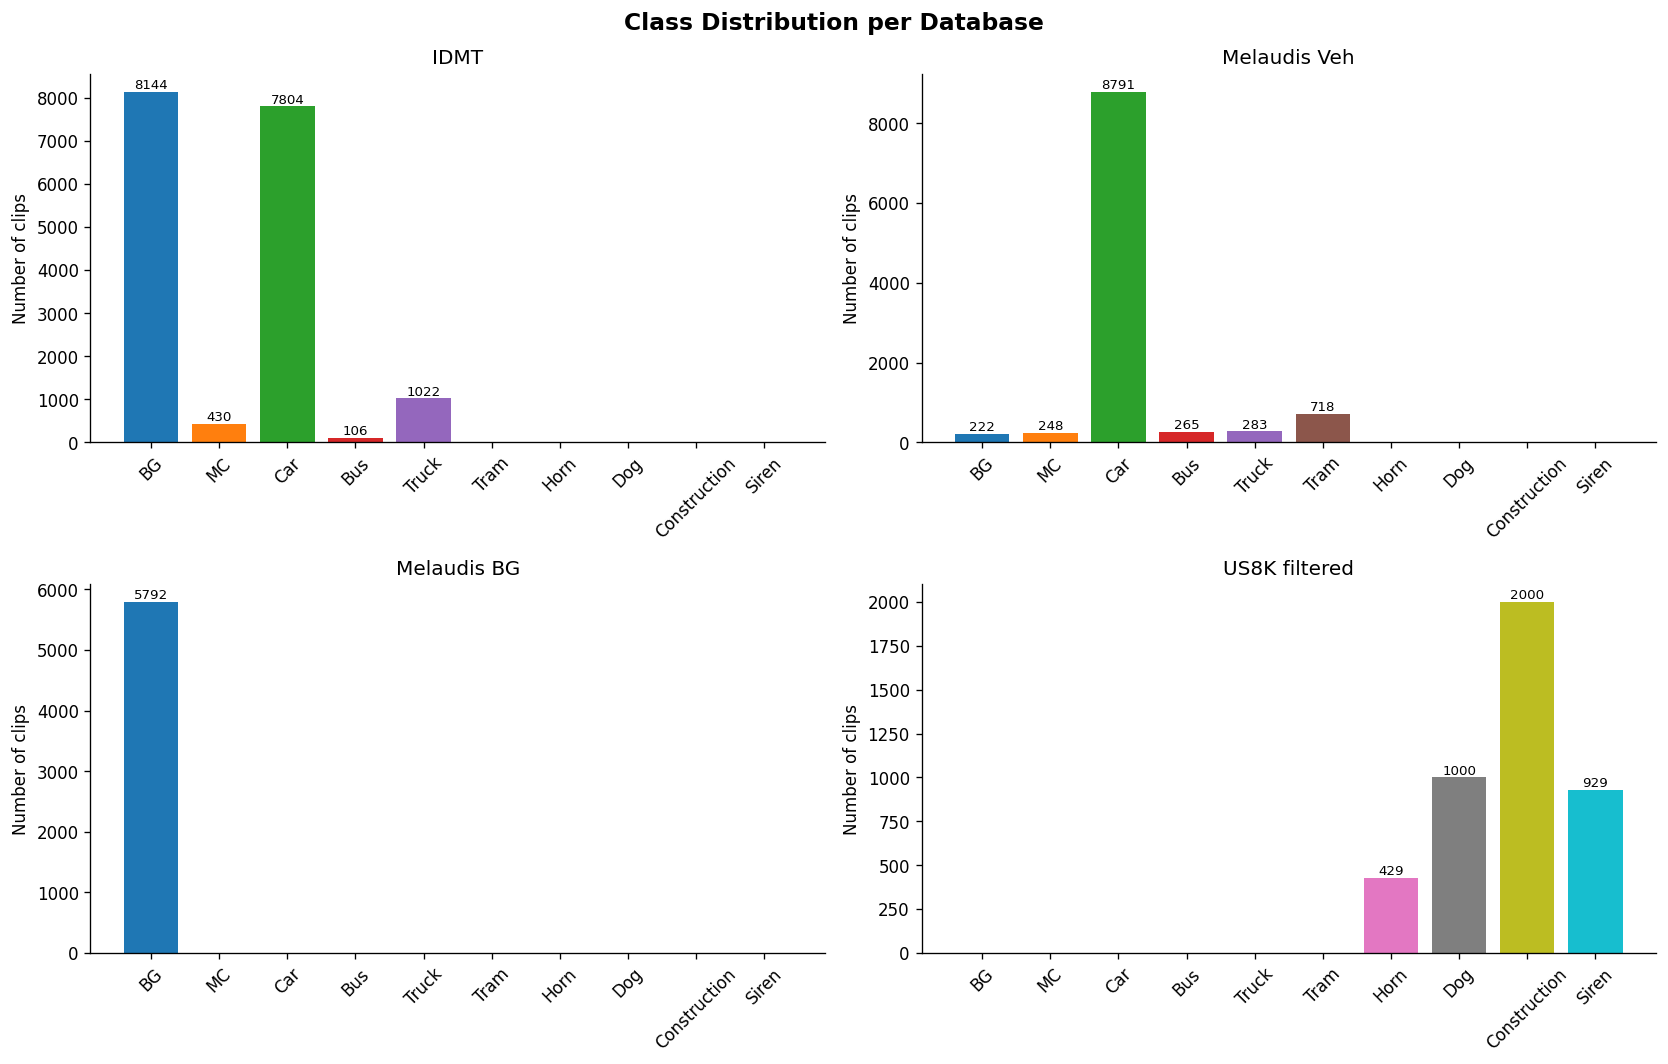

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Class Distribution per Database", fontsize=14, fontweight='bold')

sources = [
    ('IDMT',         idmt_files,                   axes[0,0]),
    ('Melaudis Veh', mel_veh,                       axes[0,1]),
    ('Melaudis BG',  mel_bg.assign(label='BG'),     axes[1,0]),
    ('US8K filtered',us8k,                          axes[1,1]),
]

colors = plt.cm.tab10.colors

for title, df, ax in sources:
    counts = df['label'].value_counts().reindex(CLASSES, fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=[colors[CLASS2IDX[c]] for c in counts.index])
    ax.set_title(title)
    ax.set_ylabel('Number of clips')
    ax.tick_params(axis='x', rotation=45)
    # Annotate counts on bars
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight')
plt.show()

### 6b. Overall class balance across all sources


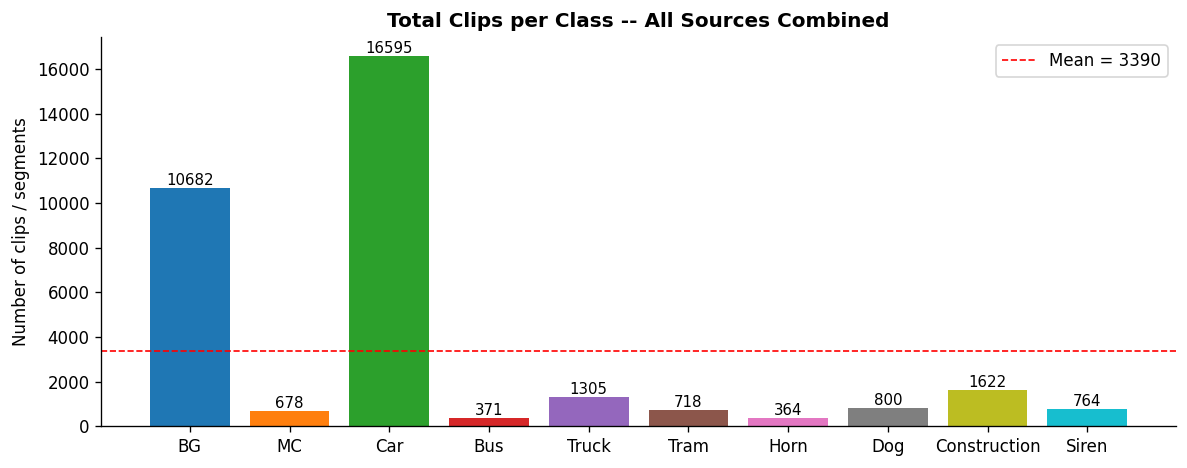

OK: All classes have at least 50 clips


In [11]:
# Total clips per class (IDMT + Melaudis_Veh + US8K train, not counting BG segments yet)
all_labels = pd.concat([
    idmt_files['label'],
    mel_veh['label'],
    us8k[us8k['split']=='train']['label'],
])

total_counts = all_labels.value_counts().reindex(CLASSES, fill_value=0)
# Add BG estimate from Melaudis_BG long files
total_counts['BG'] += mel_bg_seg_estimate

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(total_counts.index, total_counts.values,
              color=[colors[CLASS2IDX[c]] for c in total_counts.index])
ax.axhline(total_counts.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean = {total_counts.mean():.0f}')
ax.set_title('Total Clips per Class -- All Sources Combined', fontweight='bold')
ax.set_ylabel('Number of clips / segments')
ax.legend()
for bar, val in zip(bars, total_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('01_total_class_balance.png', bbox_inches='tight')
plt.show()

# Flag classes with < 50 clips
low_classes = total_counts[total_counts < 50]
if len(low_classes):
    print("WARNING:  Classes with fewer than 50 clips -- may need augmentation or additional data:")
    print(low_classes.to_string())
else:
    print("OK: All classes have at least 50 clips")

### 6c. Duration distribution (Melaudis Vehicles)

Melaudis vehicle clips are short isolated events. Checking their duration distribution shows how many will need padding versus how many are long enough to yield multiple 5s segments.


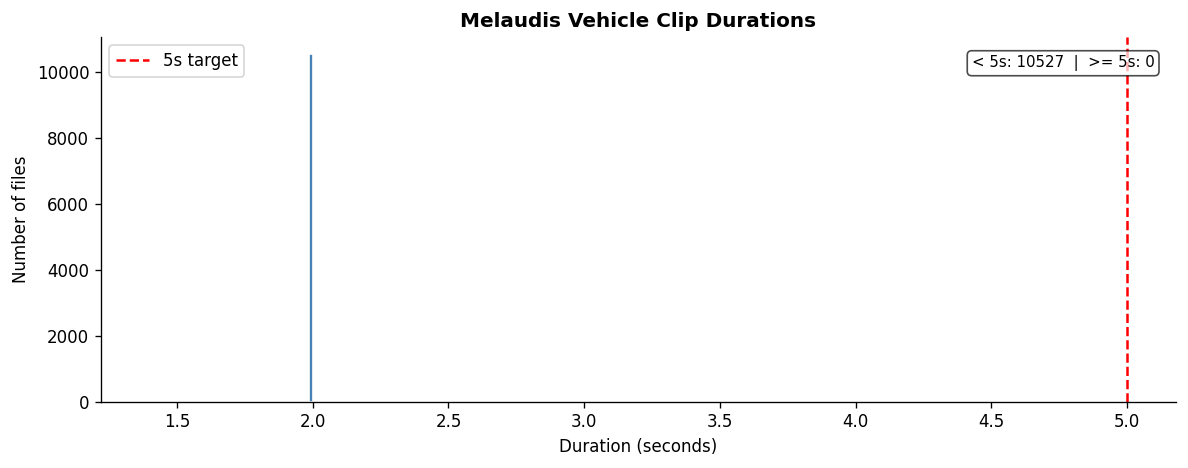

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mel_veh['duration_s'].dropna(), bins=40, color='steelblue', edgecolor='white')
ax.axvline(5, color='red', linestyle='--', linewidth=1.5, label='5s target')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Number of files')
ax.set_title('Melaudis Vehicle Clip Durations', fontweight='bold')
ax.legend()

n_short = (mel_veh['duration_s'] < 5).sum()
n_long  = (mel_veh['duration_s'] >= 5).sum()
ax.text(0.98, 0.95, f'< 5s: {n_short}  |  >= 5s: {n_long}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('01_melaudis_durations.png', bbox_inches='tight')
plt.show()

---
## 7. Audio sanity check

For each class, load one example, display its waveform and mel spectrogram, and play it. This confirms that label parsing is correct.


In [13]:
def load_mono_22k(path, duration=5.0):
    """Load up to `duration` seconds, convert to mono, resample to 22050 Hz."""
    y, sr = librosa.load(path, sr=22050, mono=True, duration=duration)
    return y, sr

def plot_sample(y, sr, label, source, ax_wave, ax_mel):
    """Plot waveform and log-mel spectrogram for a single clip."""
    # Waveform
    times = np.linspace(0, len(y)/sr, len(y))
    ax_wave.plot(times, y, linewidth=0.5, color='steelblue')
    ax_wave.set_title(f"{label}  [{source}]", fontweight='bold')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_xlabel('Time (s)')

    # Log-mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                             fmax=8000, ax=ax_mel, cmap='magma')
    ax_mel.set_title('Log-mel spectrogram')

In [14]:
# ── Pick one representative file per class ───────────────────────────────────
# Priority: Melaudis_Veh > IDMT > US8K

sample_files = {}  # class -> (path, source)

for cls in CLASSES:
    # 1. Melaudis Vehicles
    subset = mel_veh[mel_veh['label'] == cls]
    if len(subset):
        sample_files[cls] = (subset.iloc[0]['file'], 'Melaudis')
        continue
    # 2. IDMT
    subset = idmt_files[idmt_files['label'] == cls]
    if len(subset):
        sample_files[cls] = (subset.iloc[0]['file'], 'IDMT')
        continue
    # 3. US8K
    subset = us8k[us8k['label'] == cls]
    if len(subset):
        sample_files[cls] = (subset.iloc[0]['file'], 'US8K')
        continue
    # 4. Melaudis BG
    if cls == 'BG' and len(mel_bg):
        sample_files[cls] = (mel_bg.iloc[0]['file'], 'Melaudis_BG')

missing = [c for c in CLASSES if c not in sample_files]
if missing:
    print(f"WARNING:  No sample found for: {missing}")
else:
    print("OK: Found a sample for every class")

OK: Found a sample for every class


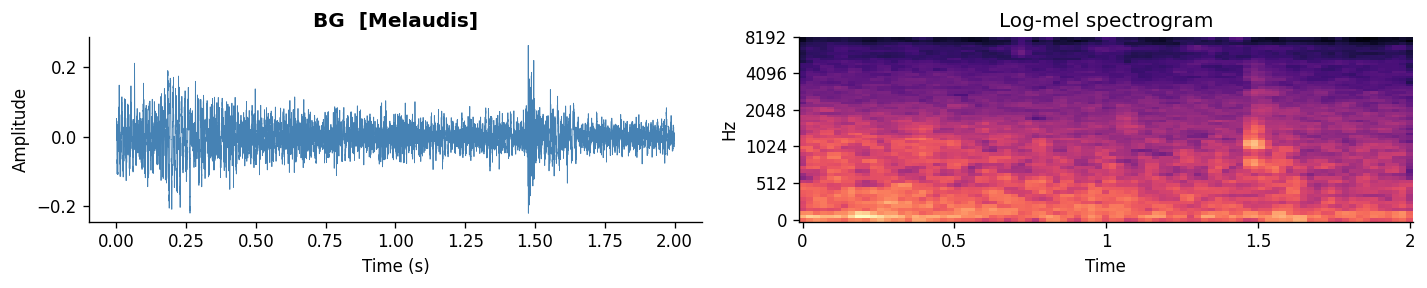

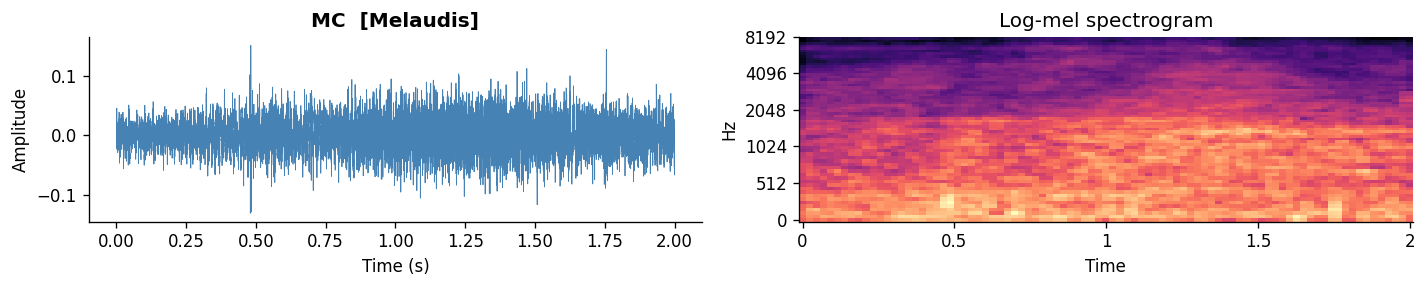

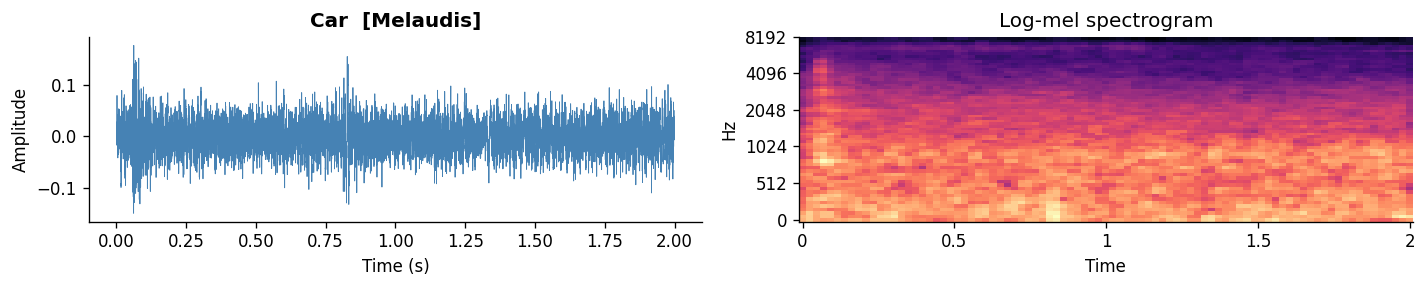

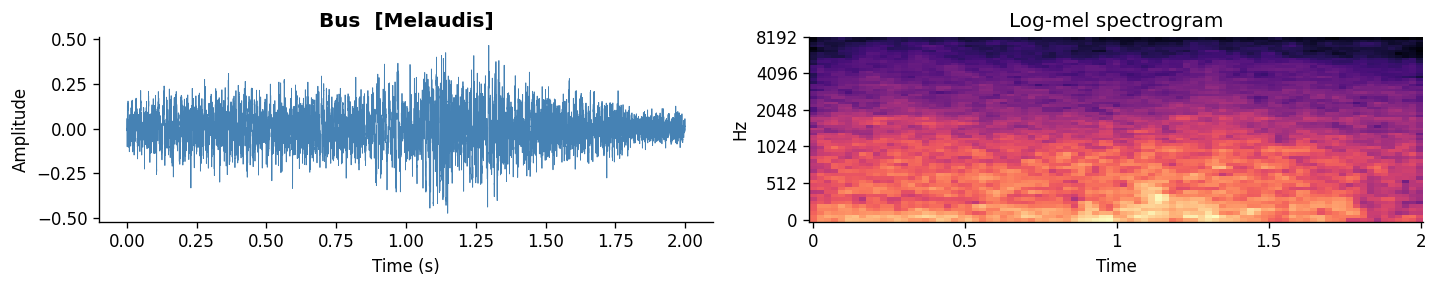

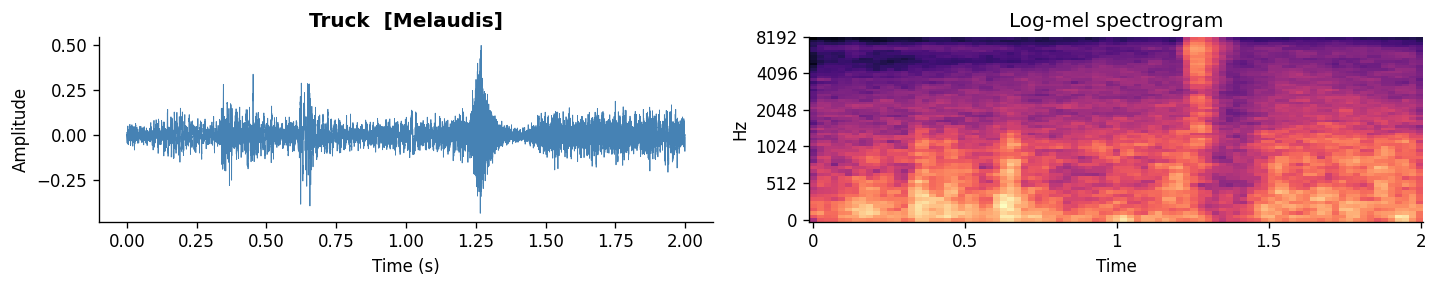

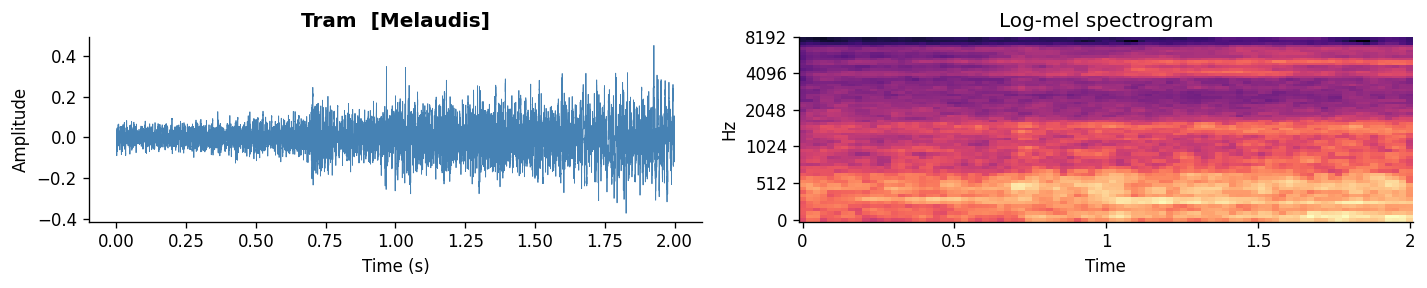

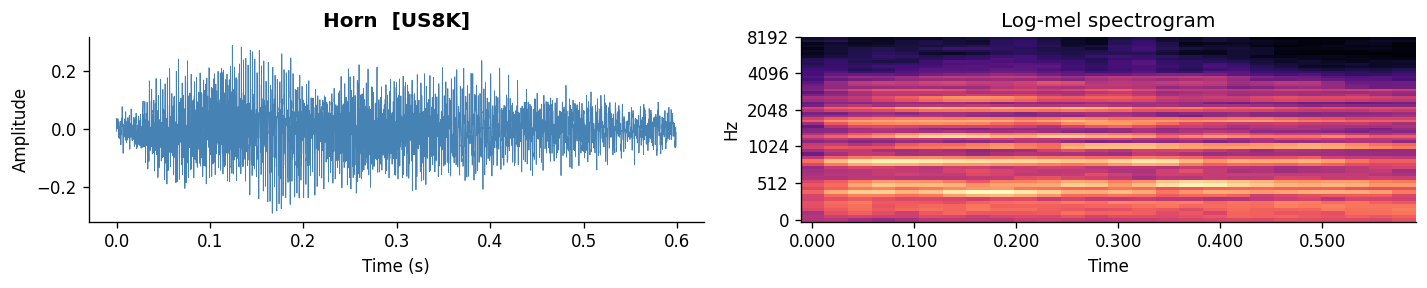

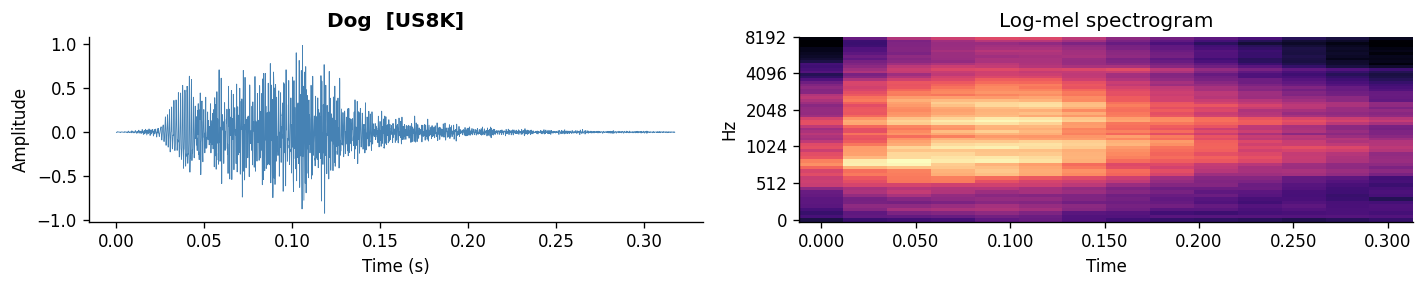

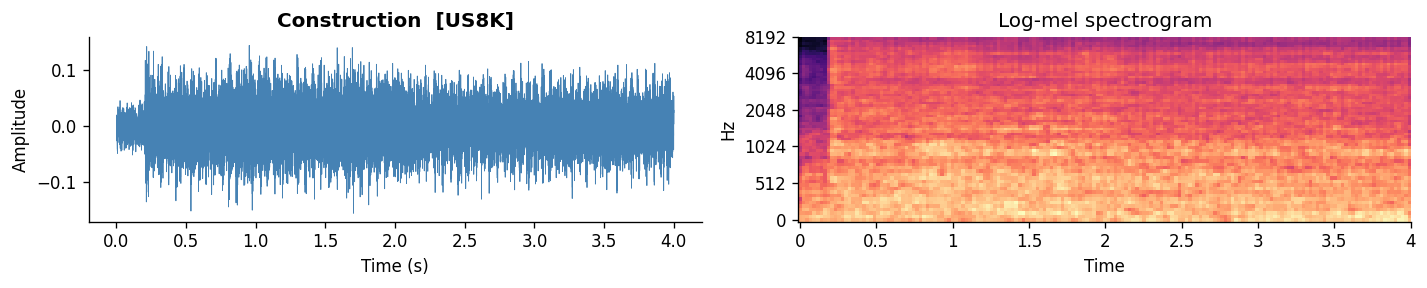

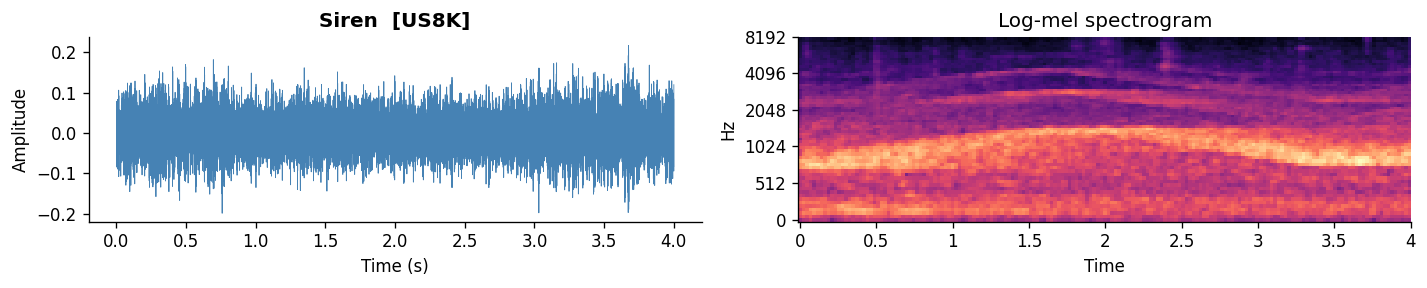

In [15]:
# ── Plot & play each class ────────────────────────────────────────────────────
for cls, (path, source) in sample_files.items():
    try:
        y, sr = load_mono_22k(path)
    except Exception as e:
        print(f"Could not load {cls}: {e}")
        continue

    fig, (ax_w, ax_m) = plt.subplots(1, 2, figsize=(12, 2.5))
    plot_sample(y, sr, cls, source, ax_w, ax_m)
    plt.tight_layout()
    plt.show()

    display(Audio(data=y, rate=sr))

---
## 8. Summary

Printed overview of file counts and class coverage across all three databases.


In [16]:
print("=" * 60)
print("EXPLORATION SUMMARY")
print("=" * 60)

print(f"\n{'Database':<20} {'Files':>8}  Classes covered")
print("-" * 60)
print(f"{'IDMT-Traffic':<20} {len(idmt_files):>8}  {sorted(idmt_files['label'].unique())}")
print(f"{'Melaudis BG':<20} {len(mel_bg):>8}  ['BG'] -- ~{mel_bg_seg_estimate} segments")
print(f"{'Melaudis Vehicles':<20} {len(mel_veh):>8}  {sorted(mel_veh['label'].unique())}")
print(f"{'US8K filtered':<20} {len(us8k):>8}  {sorted(us8k['label'].unique())}")

print("\n" + "=" * 60)
print("TOTAL PER CLASS (raw counts, before 5s segmentation)")
print("=" * 60)
print(total_counts.to_string())

print("\n" + "=" * 60)
print("CLASSES WITH FEWER THAN 50 CLIPS")
print("=" * 60)
low_classes = total_counts[total_counts < 50]
if len(low_classes):
    print(low_classes.to_string())
else:
    print("All classes have at least 50 clips.")

print("\nTarget for notebook 02: 22050 Hz, mono, 5s clips.")


EXPLORATION SUMMARY

Database                Files  Classes covered
------------------------------------------------------------
IDMT-Traffic            17506  ['BG', 'Bus', 'Car', 'MC', 'Truck']
Melaudis BG              5792  ['BG'] -- ~2316 segments
Melaudis Vehicles       10527  ['BG', 'Bus', 'Car', 'MC', 'Tram', 'Truck']
US8K filtered            4358  ['Construction', 'Dog', 'Horn', 'Siren']

TOTAL PER CLASS (raw counts, before 5s segmentation)
label
BG              10682
MC                678
Car             16595
Bus               371
Truck            1305
Tram              718
Horn              364
Dog               800
Construction     1622
Siren             764

CLASSES WITH FEWER THAN 50 CLIPS
All classes have at least 50 clips.

Target for notebook 02: 22050 Hz, mono, 5s clips.
